# Gaussian Shell


In [1]:
import numpy as np
import dynesty
from dynesty import NestedSampler
from dynesty import utils as dyfunc
import matplotlib.pyplot as plt
import corner
from dynesty import DynamicNestedSampler
import g_shell as gs
import morphZ
# import logging
# from morphZ import setup_logging ; setup_logging(level=logging.INFO)
from scipy.special import logsumexp


In [2]:
 

# Prior cube: [-L, L]^D 
L = 6.0
ndim = 30
prior_volume = (2*L)**ndim

# Parameters of the twin shells (from paper)
w1 = w2 = 0.1  # thickness of both shells
r1 = r2 = 2.0  # radius of both shells
c1 = np.array([-3.5] + [0.0] * (ndim - 1))  # center of first shell
c2 = np.array([3.5] + [0.0] * (ndim - 1))   # center of second shell

def logprior(theta):
    """Uniform prior over [-L, L]^D."""
    if np.all(np.abs(theta) <= L):
        return -np.log(prior_volume)
    else:
        return -np.inf

def loglikelihood(theta):
    """
    Twin Gaussian shell log-likelihood from equation (38) in the paper.
    L(θ) = (1/√(2πw₁)) * exp[-(|θ-c₁|-r₁)²/(2w₁²)] + (1/√(2πw₂)) * exp[-(|θ-c₂|-r₂)²/(2w₂²)]
    """
    # Distance from centers
    r_c1 = np.linalg.norm(theta - c1)
    r_c2 = np.linalg.norm(theta - c2)
    
    # Log-likelihood components for each shell
    # Note: We work in log space for numerical stability
    log_norm1 = -0.5 * np.log(2 * np.pi * w1**2)
    log_norm2 = -0.5 * np.log(2 * np.pi * w2**2)
    
    log_exp1 = log_norm1 - 0.5 * ((r_c1 - r1) / w1)**2
    log_exp2 = log_norm2 - 0.5 * ((r_c2 - r2) / w2)**2
    
    # Use logsumexp for numerical stability when adding exponentials
    return logsumexp([log_exp1, log_exp2])

def prior_transform(u):
    """
    Map unit cube [0,1]^D to [-L, L]^D.
    u: array in [0,1]^D
    """
    return -L + 2*L*u

# Optional: Visualization function for 2D case
def plot_twin_shells_2d():
    """Plot the twin Gaussian shells for visualization (2D only)."""
    if ndim != 2:
        print("Visualization only available for 2D case")
        return
    
    # Create grid
    x = np.linspace(-6, 6, 200)
    y = np.linspace(-6, 6, 200)
    X, Y = np.meshgrid(x, y)
    
    # Evaluate likelihood on grid
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            theta = np.array([X[i,j], Y[i,j]])
            Z[i,j] = np.exp(loglikelihood(theta))
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.contourf(X, Y, Z, levels=50, cmap='viridis')
    plt.colorbar(label='Likelihood')
    plt.xlabel('θ₁')
    plt.ylabel('θ₂')
    plt.title('Twin Gaussian Shells')
    
    # Mark centers
    plt.plot(c1[0], c1[1], 'r*', markersize=15, label='Center 1')
    plt.plot(c2[0], c2[1], 'r*', markersize=15, label='Center 2')
    
    # Draw circles showing the shell radii
    circle1 = plt.Circle(c1[:2], r1, fill=False, color='red', linestyle='--', alpha=0.7)
    circle2 = plt.Circle(c2[:2], r2, fill=False, color='red', linestyle='--', alpha=0.7)
    plt.gca().add_patch(circle1)
    plt.gca().add_patch(circle2)
    
    plt.legend()
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage with dynesty
def run_dynesty_example():
    """Example of how to use this with dynesty."""
    try:
        import dynesty
        from dynesty import plotting as dyplot
        
        # Run nested sampling
        sampler = dynesty.NestedSampler(loglikelihood, prior_transform, ndim)
        sampler.run_nested()
        results = sampler.results
        
        print(f"Log evidence: {results.logz[-1]:.2f} ± {results.logzerr[-1]:.2f}")
        
        # Plot results
        fig, axes = dyplot.runplot(results)
        plt.show()
        
        return results
        
    except ImportError:
        print("Dynesty not installed. Install with: pip install dynesty")
        return None

# Analytical log-evidence values from the paper (for reference)
analytical_logz = {
    20: -36.09, # 20D case from paper
    30: -60.13  # 30D case from paper
}



if __name__ == "__main__":
    print(f"Twin Gaussian Shell Problem Setup:")
    print(f"Dimensions: {ndim}")
    print(f"Prior bounds: [{-L}, {L}]^{ndim}")
    print(f"Shell centers: c1={c1}, c2={c2}")
    print(f"Shell radii: r1={r1}, r2={r2}")
    print(f"Shell widths: w1={w1}, w2={w2}")
    
    if ndim == 2:
        print("\nGenerating 2D visualization...")
        plot_twin_shells_2d()
    
    # Uncomment to run dynesty example
    # results = run_dynesty_example()


# -------------------------------
# Run dynesty Nested Sampling
# -------------------------------
NN = 1

log_z_NS = np.zeros(NN)
log_z_NS_err = np.zeros(NN)

for i in range(NN):
# Set up the sampler
    sampler = NestedSampler(
        loglikelihood,
        prior_transform,
        ndim,
        nlive=100,      # number of live points; increase for accuracy
        sample="rwalk",  # random-walk proposals; can try "unif", "slice"
        bound="multi",   # bounding method ("multi" good for multimodal)
    )
    # sampler = DynamicNestedSampler(
    #     loglikelihood,
    #     prior_transform,
    #     ndim,
    #     nlive=4000,
    #     )

    print("Running dynesty Nested Sampling on Gaussian shell...")
    sampler.run_nested(dlogz=0.01,print_progress=True)
    # sampler.run_nested(dlogz_init=0.1,print_progress=True)
    res = sampler.results
    samples, weights = res.samples, np.exp(res.logwt - res.logz[-1])
    posterior_samples = dyfunc.resample_equal(samples, weights)
    # -------------------------------
    # Report results
    # -------------------------------
    log_z_NS[i] = res.logz[-1]
    log_z_NS_err[i] = res.logzerr[-1]
true_lnZ = {10: -14.59, 30: -60.13}.get(ndim)
print("\n==== RESULTS ====")
print(f"dynesty estimated logZ = {log_z_NS.mean():.3f} ± {log_z_NS_err.mean():.3f}")
print(f"True logZ (literature) = {true_lnZ:.3f}")
print(f"Error = {log_z_NS.mean()- true_lnZ:.3f}")


Twin Gaussian Shell Problem Setup:
Dimensions: 30
Prior bounds: [-6.0, 6.0]^30
Shell centers: c1=[-3.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0. ], c2=[3.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
Shell radii: r1=2.0, r2=2.0
Shell widths: w1=0.1, w2=0.1
Running dynesty Nested Sampling on Gaussian shell...


5605it [00:12, 441.92it/s, +100 | bound: 403 | nc: 1 | ncall: 266989 | eff(%):  2.138 | loglstar:   -inf <  1.384 <    inf | logz: -49.772 +/-  0.706 | dlogz:  0.000 >  0.010]


==== RESULTS ====
dynesty estimated logZ = -49.772 ± 0.719
True logZ (literature) = -60.130
Error = 10.358


In [4]:
samples = posterior_samples[::2,:]  # total_samples[::20,:]
tot_len , ndim = samples.shape
print('Total samples:', tot_len, 'Dimensions:', ndim)
log_prob = np.zeros(tot_len)

def lp_fn(theta):
    return loglikelihood(theta)+logprior(theta)

for i in range(tot_len):
    log_prob[i] = lp_fn(samples[i,:])

log_p_estimate = morphZ.evidence(samples,lp_fn,log_prob,
n_resamples=5000,
thin=1,n_estimations=1,morph_type="2_group",output_path='./gaussian_shell/',overwrite_path=True)
# print('True:', true_logz)

print(f'MorphZ mean ln(Z): {log_p_estimate[0][0]} +/- {log_p_estimate[0][1]}')
print(f'NS  mean ln(Z): {log_z_NS.mean()} +/- {log_z_NS_err.mean()}')
if true_lnZ is not None:
    print(f'True   ln(Z) D={ndim}: {true_lnZ}')
    print(f'MorphZ residual: {log_p_estimate[0][0] - true_lnZ}')
    print(f'NS  residual: {log_z_NS.mean() - true_lnZ}')

INFO:morphZ.morph:Using Morph_Group for proposal distribution.
INFO:morphZ.morph:Group file not found at ./gaussian_shell//params_2-order_TC.json. Running total correlation computation...
INFO:morphZ.morph:Computing TC with 8 workers.
INFO:morphZ.Nth_TC:Auto-thinning samples to 300 for faster TC computation (n_dims=30, n_order=2).


Total samples: 2853 Dimensions: 30


MI pairs:   0%|          | 0/435 [00:00<?, ?it/s]

INFO:morphZ.Nth_TC:Top 10 MI pairs:
INFO:morphZ.Nth_TC:  param_1 — param_4 : 0.121277
INFO:morphZ.Nth_TC:  param_12 — param_23 : 0.116044
INFO:morphZ.Nth_TC:  param_3 — param_21 : 0.109586
INFO:morphZ.Nth_TC:  param_12 — param_22 : 0.106913
INFO:morphZ.Nth_TC:  param_3 — param_12 : 0.105520
INFO:morphZ.Nth_TC:  param_5 — param_29 : 0.104488
INFO:morphZ.Nth_TC:  param_7 — param_19 : 0.103079
INFO:morphZ.Nth_TC:  param_18 — param_29 : 0.102791
INFO:morphZ.Nth_TC:  param_1 — param_3 : 0.100580
INFO:morphZ.Nth_TC:  param_15 — param_19 : 0.100395
INFO:morphZ.Nth_TC:All MI pairs saved to gaussian_shell/params_2-order_TC.json
INFO:morphZ.morph:BW file not found at ./gaussian_shell//bw_silverman_2D.json. Running Bw with silverman...
INFO:morphZ.bw_method:Bandwidths saved to ./gaussian_shell/bw_silverman_2D.json
INFO:morphZ.bw_method:Processed 15 groups and 0 single parameters


Evaluating proposal samples:   0%|          | 0/5000 [00:00<?, ?it/s]

INFO:morphZ.bridge:Filtered proposal samples: 5000 valid samples out of 5000 total samples.
INFO:morphZ.bridge:iteration: 1 log(z) old: -60.2888435848692 log(z) New: -61.186854998650155
INFO:morphZ.bridge:iteration: 2 log(z) old: -61.186854998650155 log(z) New: -61.4448073620327
INFO:morphZ.bridge:iteration: 3 log(z) old: -61.4448073620327 log(z) New: -61.521566690857924
INFO:morphZ.bridge:iteration: 4 log(z) old: -61.521566690857924 log(z) New: -61.54453650174945
INFO:morphZ.bridge:iteration: 5 log(z) old: -61.54453650174945 log(z) New: -61.551418723977584
INFO:morphZ.bridge:Converged in 5 iterations. log(z): -61.5445 +/-: 0.0207


MorphZ mean ln(Z): -61.54453650174945 +/- 0.020651312482686066
NS  mean ln(Z): -49.771655806747845 +/- 0.7192905691184984
True   ln(Z) D=30: -60.13
MorphZ residual: -1.4145365017494456
NS  residual: 10.358344193252158


INFO:morphZ.morph_pairwise:Selected pair: param_0, param_1 (MI=0.1183)
INFO:morphZ.morph_pairwise:Pairs selected (1): [('param_0', 'param_1', 0.11825338311479032)]
INFO:morphZ.morph_pairwise:Singles (28): ['param_10', 'param_11', 'param_12', 'param_13', 'param_14', 'param_15', 'param_16', 'param_17', 'param_18', 'param_19', 'param_2', 'param_20', 'param_21', 'param_22', 'param_23', 'param_24', 'param_25', 'param_26', 'param_27', 'param_28', 'param_29', 'param_3', 'param_4', 'param_5', 'param_6', 'param_7', 'param_8', 'param_9']
INFO:morphZ.morph_pairwise:Saved selection to /home/apokrypha/Local NT/paper_tests_morph/morphZ_gaussian_shell/selected_pairs.json
INFO:morphZ.morph_pairwise:approx kde for pair['param_0', 'param_1'] with bw: 0.02


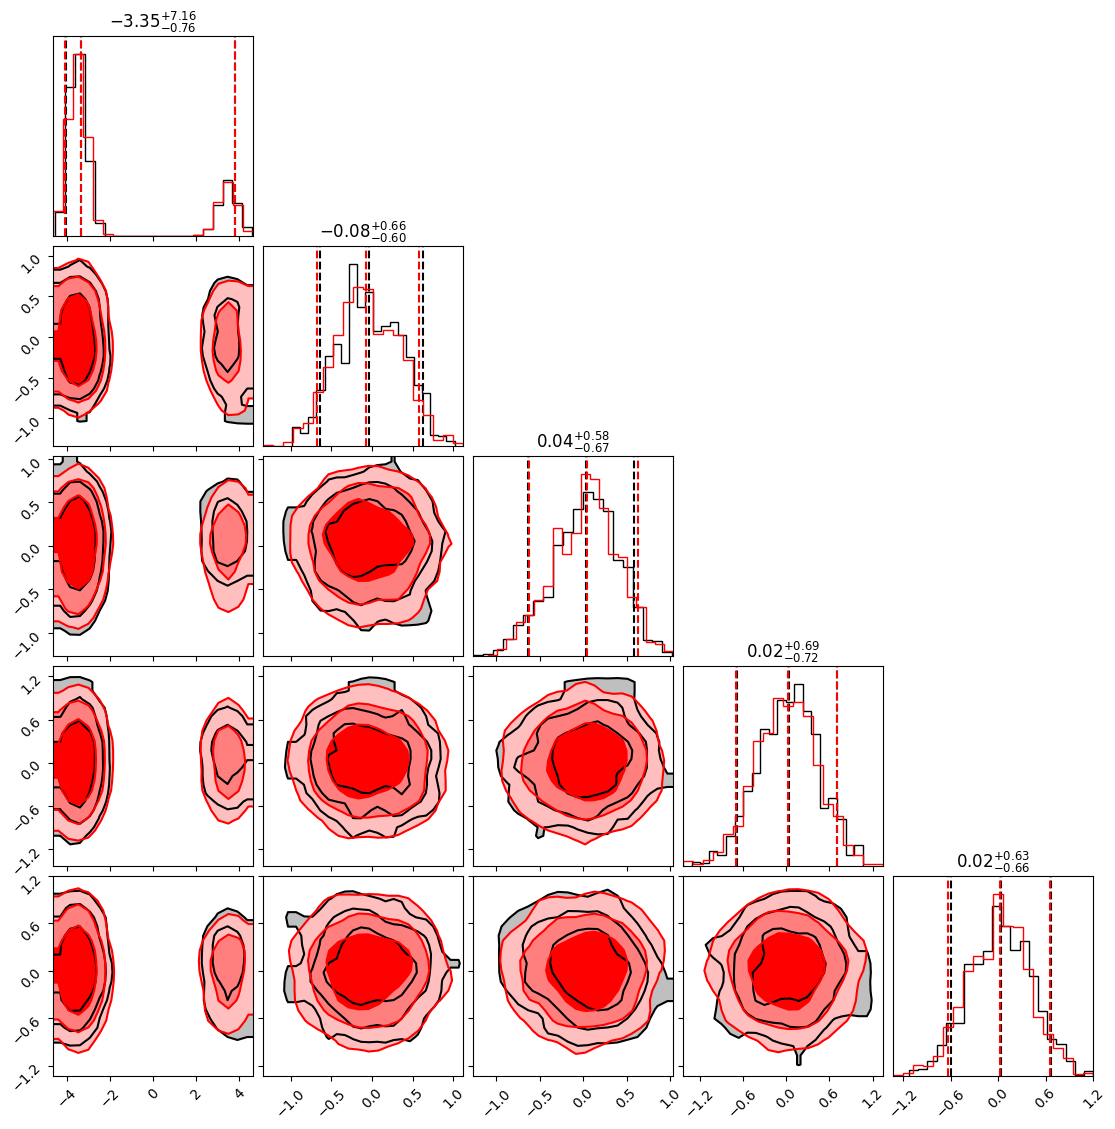

In [13]:
pair_kde = morphZ.PairwiseKDE(samples,'/home/apokrypha/Local NT/paper_tests_morph/morphZ_gaussian_shell/params_MI.json',kde_bw=0.02,verbose=True)
pair_samples = pair_kde.resample(2000)
indep_kde = morphZ.KDE_approx(posterior_samples,kde_bw=0.02)
indep_samples = indep_kde.resample(2000)
fig = corner.corner(
    posterior_samples[::10,:5], bins=20,label_kwargs = {"fontsize": 7},truth_color="dodgerblue",hist_kwargs={"density": True},quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    fontzise=6,
    title_fmt=".2f",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.8, 0.95),         
    smooth=1.0  
)
corner.corner(
    pair_samples[:,:5],color="red", bins=20,label_kwargs = {"fontsize": 7},truth_color="dodgerblue",hist_kwargs={"density": True},quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    fig=fig,
    fontzise=6,
    title_fmt=".2f",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.8, 0.95),         
    smooth=1.0  
)

plt.show()